# SVM vs VQC — Comparison

This notebook loads pre-computed results from:
- `../classical/svm_results.json`
- `../quantum/vqc_results.json`

and generates all comparison plots and summary tables.

**No model is trained here.** Re-run this notebook freely without touching
the training notebooks.

If 4-feature results are also available (`*_4f.json`), set `COMPARE_4F = True`
to include a 2-feature vs 4-feature comparison section.

## Imports

In [31]:
import json
import os
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.gridspec as gridspec

from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay

## Configuration

In [32]:
COMPARE_4F = False   # set True when 4-feature results are available

SVM_FILE    = "../classical/svm_results.json"
VQC_FILE    = "../quantum/vqc_results.json"
SVM_4F_FILE = "../classical/svm_results_4f.json"
VQC_4F_FILE = "../quantum/vqc_results_4f.json"

for f in [SVM_FILE, VQC_FILE]:
    if not os.path.exists(f):
        raise FileNotFoundError(
            f"Missing results file: {f}\n"
            "Run svm.ipynb and vqc.ipynb first."
        )

if COMPARE_4F:
    for f in [SVM_4F_FILE, VQC_4F_FILE]:
        if not os.path.exists(f):
            raise FileNotFoundError(f"Missing 4-feature results file: {f}")

print("Results files found — ready to compare.")

Results files found — ready to compare.


## Load Results

In [33]:
with open(SVM_FILE) as f:
    svm = json.load(f)

with open(VQC_FILE) as f:
    vqc = json.load(f)

if COMPARE_4F:
    with open(SVM_4F_FILE) as f:
        svm4 = json.load(f)
    with open(VQC_4F_FILE) as f:
        vqc4 = json.load(f)

print("SVM results loaded:")
print(f"  Test accuracy : {svm['accuracy_test']:.4f}")
print(f"  Train time    : {svm['train_time_s']:.4f} s")
print()
print("VQC results loaded:")
print(f"  Test accuracy (sim)  : {vqc['accuracy_test_sim']:.4f}")
if vqc.get('real_hw_run'):
    print(f"  Test accuracy (real) : {vqc['accuracy_test_real']:.4f}")
print(f"  Train time (sim)     : {vqc['train_time_sim_s']:.2f} s")

SVM results loaded:
  Test accuracy : 0.8500
  Train time    : 0.0030 s

VQC results loaded:
  Test accuracy (sim)  : 0.7000
  Train time (sim)     : 232.41 s


## Plot 1 — Accuracy Comparison

Bar chart comparing test accuracy of SVM vs VQC (simulator, and real hardware if available).
Also shows SVM cross-validation mean ± std.

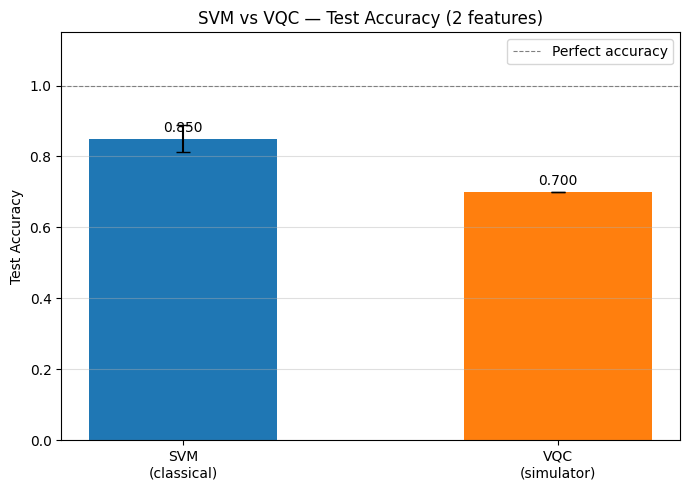

VQC error bar: ±0.0000 over 3 runs with seeds [42, 123, 7]


In [34]:
labels  = ["SVM\n(classical)", "VQC\n(simulator)"]
values  = [svm["accuracy_test"], vqc.get("accuracy_test_mean", vqc["accuracy_test_sim"])]
colors  = ["tab:blue", "tab:orange"]
yerr    = [svm["cv_std"], vqc.get("accuracy_test_std", 0)]

if vqc.get("real_hw_run") and vqc.get("accuracy_test_real") is not None:
    labels.append("VQC\n(real HW)")
    values.append(vqc["accuracy_test_real"])
    colors.append("tab:red")
    yerr.append(0)

x = np.arange(len(labels))
fig, ax = plt.subplots(figsize=(7, 5))
bars = ax.bar(x, values, color=colors, width=0.5,
              yerr=yerr, capsize=5, error_kw={"elinewidth": 1.5})

for bar, val in zip(bars, values):
    ax.text(bar.get_x() + bar.get_width() / 2, val + 0.01,
            f"{val:.3f}", ha="center", va="bottom", fontsize=10)

ax.set_xticks(x)
ax.set_xticklabels(labels)
ax.set_ylim(0, 1.15)
ax.set_ylabel("Test Accuracy")
ax.set_title(f"SVM vs VQC — Test Accuracy ({svm['n_features']} features)")
ax.axhline(1.0, color="gray", linestyle="--", linewidth=0.8, label="Perfect accuracy")
ax.legend()
ax.grid(axis="y", alpha=0.4)
plt.tight_layout()
plt.savefig("plot1_accuracy.png", dpi=150)
plt.show()

if vqc.get("accuracy_test_std", 0) > 0:
    print(f"VQC error bar: ±{vqc['accuracy_test_std']:.4f} over {vqc['n_runs']} runs with seeds {vqc['init_seeds']}")


## Plot 2 — Training Time

The training time difference is the most striking practical gap between SVM and VQC.
Note the log scale — VQC simulation is orders of magnitude slower for this problem size.

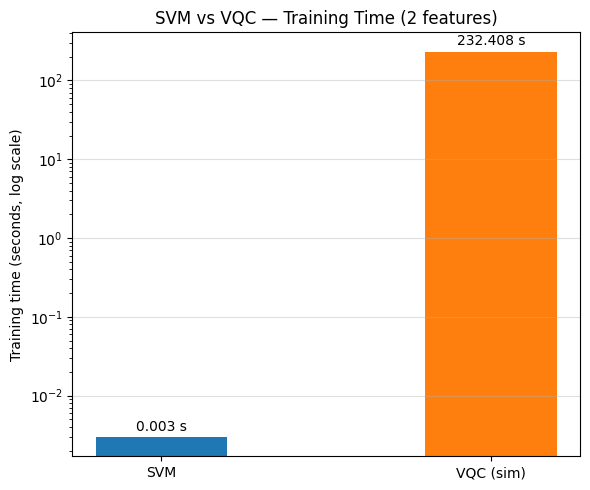

In [35]:
t_labels = ["SVM", "VQC (sim)"]
t_values = [svm["train_time_s"], vqc["train_time_sim_s"]]
t_colors = ["tab:blue", "tab:orange"]

fig, ax = plt.subplots(figsize=(6, 5))
bars = ax.bar(t_labels, t_values, color=t_colors, width=0.4)
for bar, val in zip(bars, t_values):
    ax.text(bar.get_x() + bar.get_width() / 2, val * 1.1,
            f"{val:.3f} s", ha="center", va="bottom", fontsize=10)

ax.set_yscale("log")
ax.set_ylabel("Training time (seconds, log scale)")
ax.set_title(f"SVM vs VQC — Training Time ({svm['n_features']} features)")
ax.grid(axis="y", alpha=0.4)
plt.tight_layout()
plt.savefig("plot2_training_time.png", dpi=150)
plt.show()

## Plot 5 — Accuracy / Training-time Trade-off

A single metric that combines both axes: how much accuracy do you get per unit of training time?
Higher is better. Useful for summarising the quantum vs classical trade-off in one figure.


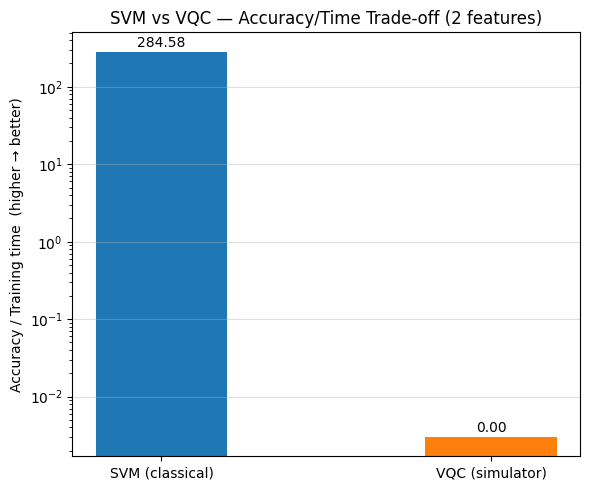

SVM  ratio: 284.58  (acc=0.850, time=0.0030s)
VQC  ratio: 0.0030  (acc=0.700, time=232.41s)


In [36]:
ratio_svm = svm["accuracy_test"]  / svm["train_time_s"]
ratio_vqc = vqc.get("accuracy_test_mean", vqc["accuracy_test_sim"]) / vqc["train_time_sim_s"]

r_labels = ["SVM (classical)", "VQC (simulator)"]
r_values = [ratio_svm, ratio_vqc]
r_colors = ["tab:blue", "tab:orange"]

fig, ax = plt.subplots(figsize=(6, 5))
bars = ax.bar(r_labels, r_values, color=r_colors, width=0.4)
for bar, val in zip(bars, r_values):
    ax.text(bar.get_x() + bar.get_width() / 2, val * 1.05,
            f"{val:.2f}", ha="center", va="bottom", fontsize=10)

ax.set_ylabel("Accuracy / Training time  (higher → better)")
ax.set_title(f"SVM vs VQC — Accuracy/Time Trade-off ({svm['n_features']} features)")
ax.set_yscale("log")
ax.grid(axis="y", alpha=0.4)
plt.tight_layout()
plt.savefig("plot5_ratio.png", dpi=150)
plt.show()

print(f"SVM  ratio: {ratio_svm:.2f}  (acc={svm['accuracy_test']:.3f}, time={svm['train_time_s']:.4f}s)")
print(f"VQC  ratio: {ratio_vqc:.4f}  (acc={vqc.get('accuracy_test_mean', vqc['accuracy_test_sim']):.3f}, time={vqc['train_time_sim_s']:.2f}s)")


## Plot 3 — VQC Loss Curve

Shows how the VQC converges during training. Useful to assess whether more iterations
would help (if the curve has not flattened, increase `MAX_ITER` in `vqc.ipynb`).

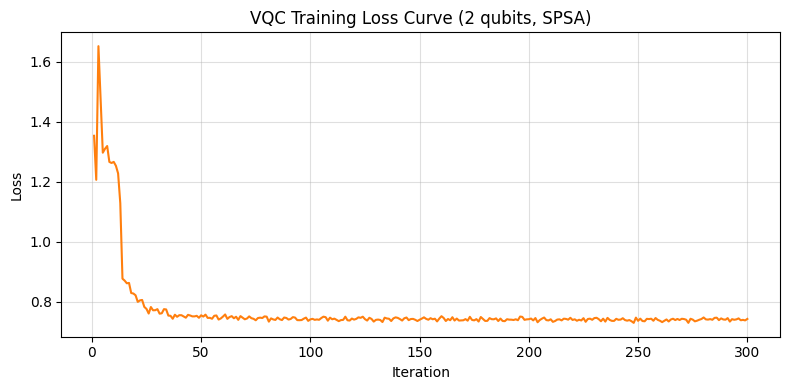

In [37]:
loss = vqc["loss_history"]

plt.figure(figsize=(8, 4))
plt.plot(range(1, len(loss) + 1), loss, color="tab:orange")
plt.xlabel("Iteration")
plt.ylabel("Loss")
plt.title(f"VQC Training Loss Curve ({vqc['n_qubits']} qubits, {vqc['optimizer']})")
plt.grid(True, alpha=0.4)
plt.tight_layout()
plt.savefig("plot3_vqc_loss.png", dpi=150)
plt.show()

## Plot 4 — Confusion Matrices Side by Side

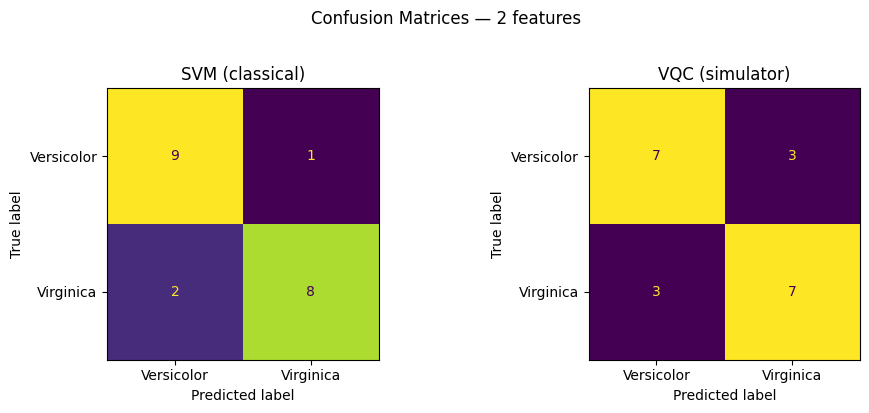

In [38]:
cm_svm = confusion_matrix(svm["y_test"], svm["y_pred_test"])
cm_vqc = confusion_matrix(vqc["y_test"], vqc["y_pred_test_sim"])

fig, axes = plt.subplots(1, 2, figsize=(10, 4))
for ax, cm, title in zip(axes,
                          [cm_svm, cm_vqc],
                          ["SVM (classical)", "VQC (simulator)"]):
    disp = ConfusionMatrixDisplay(confusion_matrix=cm,
                                   display_labels=["Versicolor", "Virginica"])
    disp.plot(ax=ax, colorbar=False)
    ax.set_title(title)

plt.suptitle(f"Confusion Matrices — {svm['n_features']} features", y=1.02)
plt.tight_layout()
plt.savefig("plot4_confusion_matrices.png", dpi=150, bbox_inches="tight")
plt.show()

## Plot 5 — 2-feature vs 4-feature Comparison (optional)

Only shown when `COMPARE_4F = True` and both 4-feature result files exist.

In [39]:
if COMPARE_4F:
    experiments = [
        ("SVM 2f",  svm["accuracy_test"],    svm["train_time_s"],    "tab:blue"),
        ("SVM 4f",  svm4["accuracy_test"],   svm4["train_time_s"],   "tab:cyan"),
        ("VQC 2f",  vqc["accuracy_test_sim"], vqc["train_time_sim_s"], "tab:orange"),
        ("VQC 4f",  vqc4["accuracy_test_sim"], vqc4["train_time_sim_s"], "tab:red"),
    ]

    names   = [e[0] for e in experiments]
    accs    = [e[1] for e in experiments]
    times   = [e[2] for e in experiments]
    colors  = [e[3] for e in experiments]

    fig, axes = plt.subplots(1, 2, figsize=(12, 5))

    axes[0].bar(names, accs, color=colors)
    for i, (name, val) in enumerate(zip(names, accs)):
        axes[0].text(i, val + 0.01, f"{val:.3f}", ha="center", fontsize=9)
    axes[0].set_ylim(0, 1.15)
    axes[0].set_ylabel("Test Accuracy")
    axes[0].set_title("Test Accuracy: 2 features vs 4 features")
    axes[0].grid(axis="y", alpha=0.4)

    axes[1].bar(names, times, color=colors)
    axes[1].set_yscale("log")
    axes[1].set_ylabel("Training time (s, log scale)")
    axes[1].set_title("Training Time: 2 features vs 4 features")
    axes[1].grid(axis="y", alpha=0.4)

    plt.tight_layout()
    plt.savefig("plot5_2f_vs_4f.png", dpi=150)
    plt.show()
else:
    print("COMPARE_4F is False — skipping 2f vs 4f comparison.")
    print("Set COMPARE_4F = True once both 4-feature result files are available.")

COMPARE_4F is False — skipping 2f vs 4f comparison.
Set COMPARE_4F = True once both 4-feature result files are available.


## Summary Table

Printed to screen and saved to `comparison_summary.json`.

In [40]:
summary = {
    "n_features"              : svm["n_features"],
    "n_train"                 : svm["n_train"],
    "n_test"                  : svm["n_test"],
    "svm_accuracy_test"       : svm["accuracy_test"],
    "svm_cv_mean"             : svm["cv_mean"],
    "svm_cv_std"              : svm["cv_std"],
    "svm_train_time_s"        : svm["train_time_s"],
    "svm_n_support_vectors"   : svm["n_support_vectors"],
    "vqc_accuracy_test_sim"   : vqc["accuracy_test_sim"],
    "vqc_accuracy_test_mean"  : vqc.get("accuracy_test_mean"),
    "vqc_accuracy_test_std"   : vqc.get("accuracy_test_std"),
    "vqc_n_runs"              : vqc.get("n_runs"),
    "vqc_accuracy_test_real"  : vqc.get("accuracy_test_real"),
    "vqc_train_time_sim_s"    : vqc["train_time_sim_s"],
    "vqc_n_qubits"            : vqc["n_qubits"],
    "vqc_n_parameters"        : vqc["n_parameters"],
    "vqc_optimizer"           : vqc["optimizer"],
    "vqc_max_iter"            : vqc["max_iter"],
    "vqc_final_loss"          : vqc["loss_history"][-1],
    "vqc_real_hw_run"         : vqc.get("real_hw_run", False),
    "vqc_backend"             : vqc.get("backend_name"),
    "ratio_svm"               : svm["accuracy_test"] / svm["train_time_s"],
    "ratio_vqc_sim"           : vqc.get("accuracy_test_mean", vqc["accuracy_test_sim"]) / vqc["train_time_sim_s"],
}

if COMPARE_4F:
    summary["svm_4f_accuracy_test"]     = svm4["accuracy_test"]
    summary["svm_4f_train_time_s"]      = svm4["train_time_s"]
    summary["vqc_4f_accuracy_test_sim"] = vqc4["accuracy_test_sim"]
    summary["vqc_4f_train_time_sim_s"]  = vqc4["train_time_sim_s"]
    summary["vqc_4f_n_parameters"]      = vqc4["n_parameters"]

with open("comparison_summary.json", "w") as f:
    json.dump(summary, f, indent=2)

col_w = 30
vqc_acc_str = (f"{vqc['accuracy_test_mean']:.4f} ± {vqc['accuracy_test_std']:.4f}"
               if vqc.get("accuracy_test_std") is not None else f"{vqc['accuracy_test_sim']:.4f}")

print(f"{'Metric':<{col_w}} {'SVM':>18} {'VQC (sim)':>22} {'VQC (real)':>12}")
print("-" * (col_w + 56))
rows = [
    ("Test accuracy",
     f"{svm['accuracy_test']:.4f}",
     vqc_acc_str,
     f"{vqc['accuracy_test_real']:.4f}" if vqc.get('accuracy_test_real') else "N/A"),
    ("Train accuracy",
     f"{svm['accuracy_train']:.4f}",
     f"{vqc['accuracy_train_sim']:.4f}",
     "N/A"),
    ("CV / multi-seed",
     f"{svm['cv_mean']:.4f} ± {svm['cv_std']:.4f}",
     vqc_acc_str,
     "N/A"),
    ("Train time (s)",
     f"{svm['train_time_s']:.4f}",
     f"{vqc['train_time_sim_s']:.2f}",
     "N/A"),
    ("Accuracy/time ratio",
     f"{svm['accuracy_test']/svm['train_time_s']:.2f}",
     f"{vqc.get('accuracy_test_mean',vqc['accuracy_test_sim'])/vqc['train_time_sim_s']:.4f}",
     "N/A"),
    ("Model params",
     f"{svm['n_support_vectors']} SVs",
     f"{vqc['n_parameters']} params",
     "—"),
]
for label, sv, vq, vr in rows:
    print(f"{label:<{col_w}} {sv:>18} {vq:>22} {vr:>12}")

print()
print("Summary saved to comparison_summary.json")


Metric                                        SVM              VQC (sim)   VQC (real)
--------------------------------------------------------------------------------------
Test accuracy                              0.8500        0.7000 ± 0.0000          N/A
Train accuracy                             0.9750                 0.7625          N/A
CV / multi-seed                   0.9400 ± 0.0374        0.7000 ± 0.0000          N/A
Train time (s)                             0.0030                 232.41          N/A
Accuracy/time ratio                        284.58                 0.0030          N/A
Model params                               17 SVs               8 params            —

Summary saved to comparison_summary.json
